## Data Cleaning, Pre-Processing, and Dimensionality Reduction 

In this notebook I will clean and wrangle the dataset based on what I found in the EDA. This includes dropping unnecessary columns, handling outliers, checking for multicollinearity, and scaling the data for clustering. 

In [1]:
#Importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

In [2]:
#Loading dataset 
df = pd.read_csv('data/music_rec/train.csv')
print(f"Original shape: {df.shape}")
df.head()

Original shape: (28362, 24)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,0.000598,0.000598,0.048857,0.017104,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,0.001284,0.001284,0.027007,0.001284,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,0.002770,0.002770,0.002770,0.158564,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,0.001548,0.021500,0.001548,0.411536,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,0.001350,0.001350,0.001350,0.463430,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


## Dropping Unnecessary Columns 
Based on EDA I will drop the following columns: 
- Unnamed
- artist_name
- track_name
- lyrics 
- topic 
- genre

I will keep release_date for now since it could be informative alongside the age feature.

In [3]:
#Dropping unnecessary columns
cols_to_drop = ['Unnamed: 0', 'artist_name', 'track_name', 'lyrics', 'topic', 'genre']

#Saving metadata before dropping so we can reference it later
metadata = df[['artist_name', 'track_name', 'genre', 'topic']].copy()

df_clean = df.drop(columns=cols_to_drop)
print(f"Shape after dropping columns: {df_clean.shape}")
print(f"\nRemaining columns: {list(df_clean.columns)}")

Shape after dropping columns: (28362, 18)

Remaining columns: ['release_date', 'len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']


## Checking for Outliers
I want to look at the distribution of our numeric features and check for any extreme outliers using boxplots. 

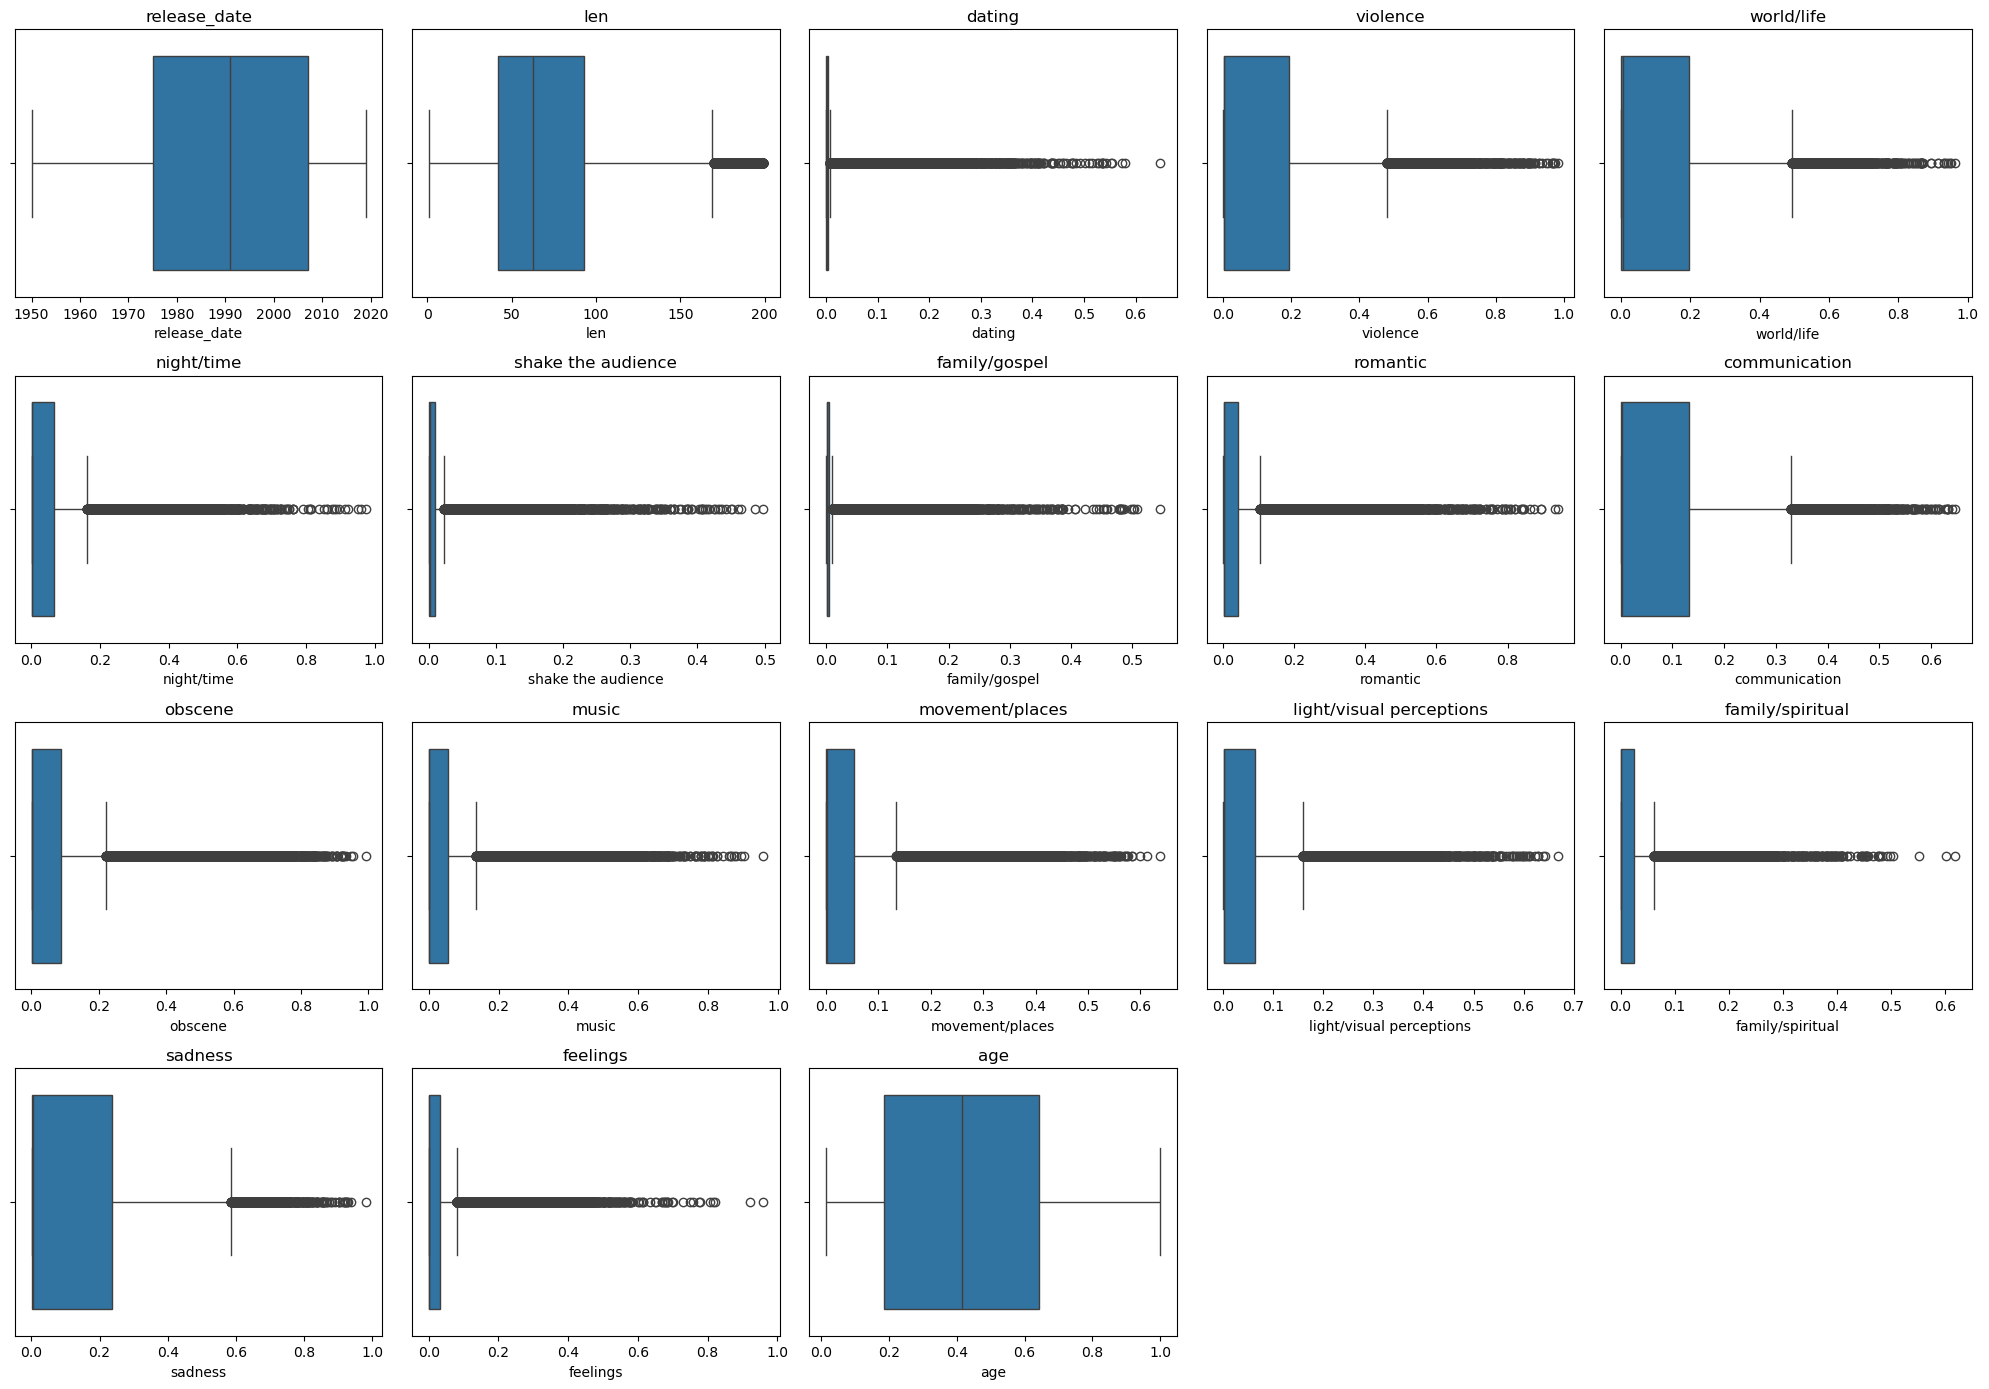

In [4]:
#Boxplots for all remaining features
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

#Hiding the empty subplot since we have 18 columns and 20 subplots
for j in range(len(df_clean.columns), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Checking for Multicollinearity 
From the EDA we found that no feature pairs were highly correlated above 0.5. The strongest correlation was between obscene the len at 0.44. Let's double check this and also look at the relationship between release_date and age since they likely measure similar things. 

In [5]:
#Checking correlation between release_date and age
corr_val = df_clean['release_date'].corr(df_clean['age'])
print(f"Correlation between release_date and age: {corr_val:.4f}")

Correlation between release_date and age: -1.0000


release_date and age have a strong negative correlation which makes sense since age is calculated from the release date. Keeping both would be redundant so I will drop release_date and keep age since it is already normalized between 0 and 1.

In [6]:
#Dropping release_date since it correlates with age
df_clean = df_clean.drop(columns=['release_date'])
print(f"Shape after dropping release_date: {df_clean.shape}")
print(f"\nRemaining columns: {list(df_clean.columns)}")

Shape after dropping release_date: (28362, 17)

Remaining columns: ['len', 'dating', 'violence', 'world/life', 'night/time', 'shake the audience', 'family/gospel', 'romantic', 'communication', 'obscene', 'music', 'movement/places', 'light/visual perceptions', 'family/spiritual', 'sadness', 'feelings', 'age']


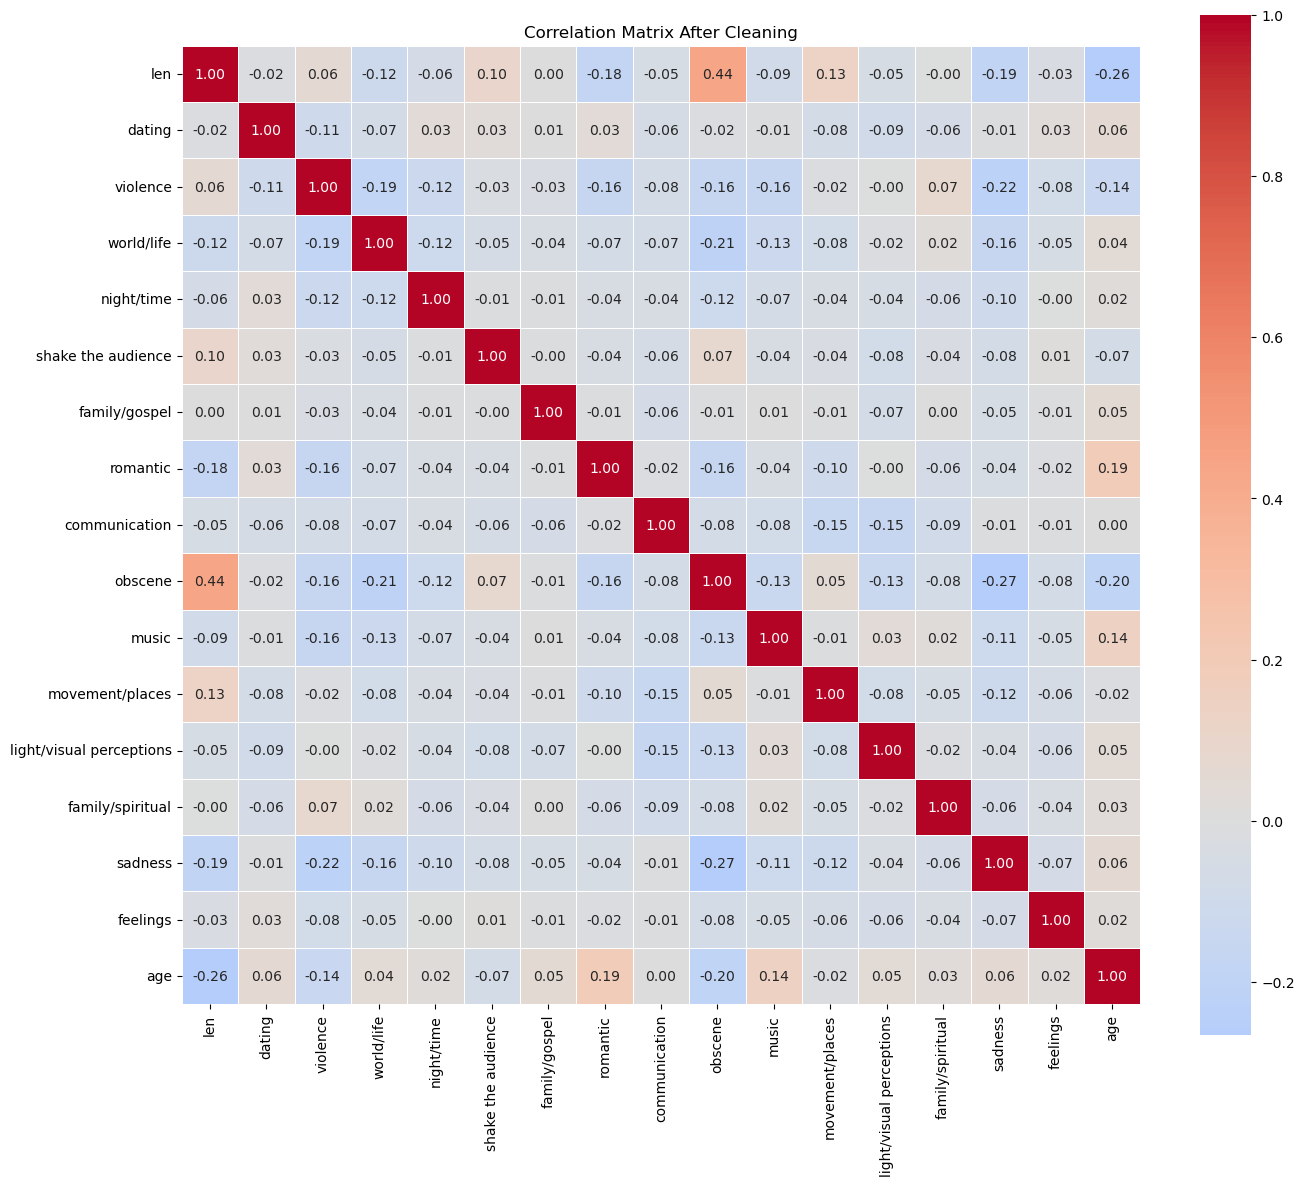

In [7]:
#Final correlation matrix to confirm no major multicollinearity
corr_matrix = df_clean.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix After Cleaning')
plt.tight_layout()
plt.show()

In [8]:
#Confirming no pairs above 0.5
print("Feature pairs with |r| > 0.5:")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.5:
            print(f"  {corr_matrix.columns[i]} & {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.4f}")
            found = True
if not found:
    print("  None found - no major multicollinearity issues")

Feature pairs with |r| > 0.5:
  None found - no major multicollinearity issues


## Feature Scaling
KMeans clustering is distance based so features need to be on the same scale. I will use StandardScaler to normalize all features to have mean 0 and standard deviation 1.

In [9]:
#Scaling the features
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

print("Scaled data statistics:")
print(df_scaled.describe().round(2))

Scaled data statistics:
            len    dating  violence  ...   sadness  feelings       age
count  28362.00  28362.00  28362.00  ...  28362.00  28362.00  28362.00
mean       0.00      0.00      0.00  ...      0.00      0.00      0.00
std        1.00      1.00      1.00  ...      1.00      1.00      1.00
min       -1.72     -0.40     -0.66  ...     -0.71     -0.43     -1.56
25%       -0.74     -0.39     -0.66  ...     -0.71     -0.42     -0.91
50%       -0.24     -0.38     -0.65  ...     -0.69     -0.41     -0.04
75%        0.48     -0.33      0.42  ...      0.58      0.02      0.82
max        3.01     11.97      4.83  ...      4.70     12.95      2.18

[8 rows x 17 columns]


In [10]:
#Verifying the scaling worked
print(f"\nMean of each feature (should be ~0):")
print(df_scaled.mean().round(4))
print(f"\nStd of each feature (should be ~1):")
print(df_scaled.std().round(4))


Mean of each feature (should be ~0):
len                         0.0
dating                      0.0
violence                    0.0
world/life                 -0.0
night/time                  0.0
shake the audience          0.0
family/gospel               0.0
romantic                    0.0
communication               0.0
obscene                     0.0
music                      -0.0
movement/places            -0.0
light/visual perceptions   -0.0
family/spiritual           -0.0
sadness                     0.0
feelings                    0.0
age                         0.0
dtype: float64

Std of each feature (should be ~1):
len                         1.0
dating                      1.0
violence                    1.0
world/life                  1.0
night/time                  1.0
shake the audience          1.0
family/gospel               1.0
romantic                    1.0
communication               1.0
obscene                     1.0
music                       1.0
movement/place

## Dimensionality Reduction with PCA
Even though we dont have a huge number of features, PCA can help us visualize the data in 2D and also reduce noise. Let's first look at how much variance each component explains to decide how many to keep.

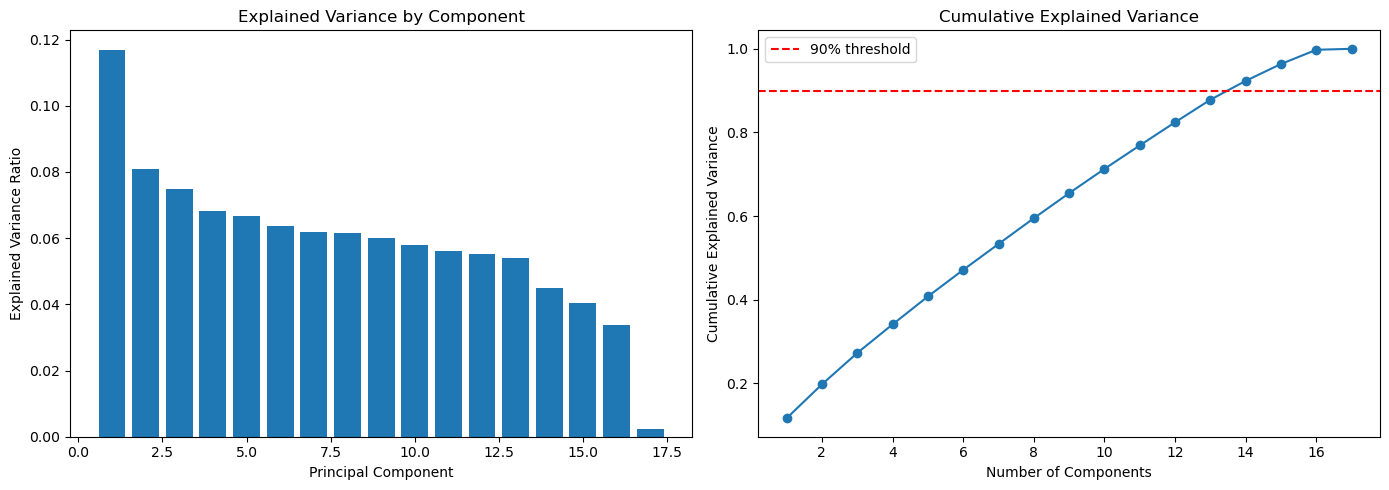

Cumulative explained variance by component:
  PC1: 0.1169 (11.7%)
  PC2: 0.1979 (19.8%)
  PC3: 0.2729 (27.3%)
  PC4: 0.3412 (34.1%)
  PC5: 0.4080 (40.8%)
  PC6: 0.4716 (47.2%)
  PC7: 0.5335 (53.4%)
  PC8: 0.5950 (59.5%)
  PC9: 0.6550 (65.5%)
  PC10: 0.7130 (71.3%)
  PC11: 0.7691 (76.9%)
  PC12: 0.8244 (82.4%)
  PC13: 0.8784 (87.8%)
  PC14: 0.9234 (92.3%)
  PC15: 0.9638 (96.4%)
  PC16: 0.9977 (99.8%)
  PC17: 1.0000 (100.0%)


In [11]:
#Fitting PCA with all components to see explained variance
pca_full = PCA()
pca_full.fit(df_scaled)

#Plotting explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
            pca_full.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance by Component')

axes[1].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
             np.cumsum(pca_full.explained_variance_ratio_), marker='o')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].legend()

plt.tight_layout()
plt.show()

#Printing the cumulative variance
print("Cumulative explained variance by component:")
for i, var in enumerate(np.cumsum(pca_full.explained_variance_ratio_)):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.1f}%)")

Variance explained by 2 components: 0.1979


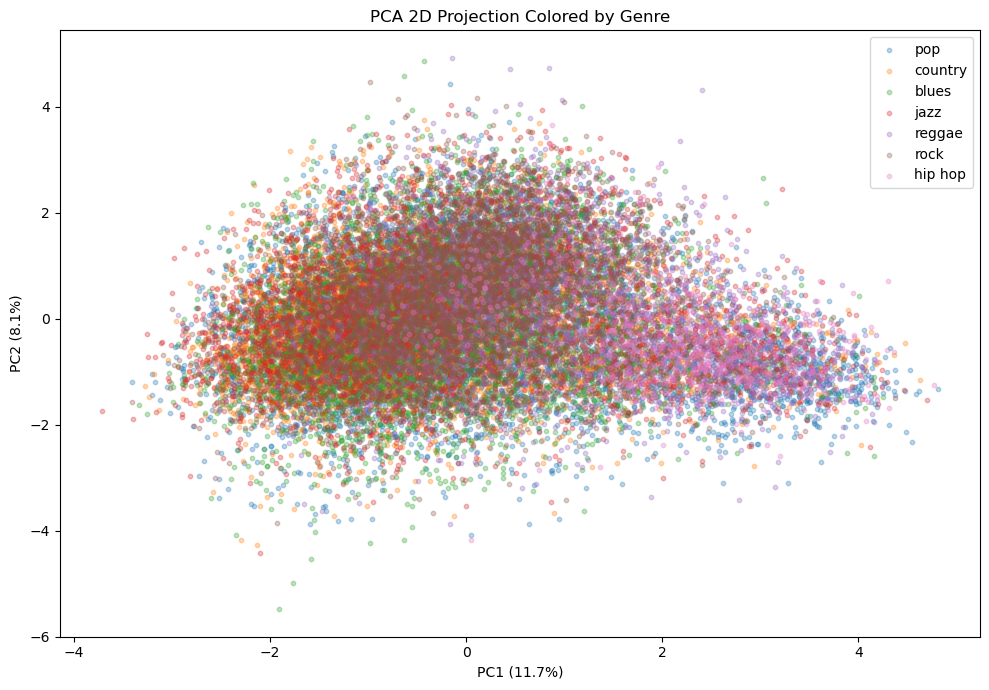

In [12]:
#Reducing to 2 components for visualization
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

print(f"Variance explained by 2 components: {sum(pca_2d.explained_variance_ratio_):.4f}")

#Scatter plot of PCA components colored by genre
plt.figure(figsize=(10, 7))
genres = metadata['genre']
for genre in genres.unique():
    mask = genres == genre
    plt.scatter(df_pca_2d[mask, 0], df_pca_2d[mask, 1], label=genre, alpha=0.3, s=10)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D Projection Colored by Genre')
plt.legend()
plt.tight_layout()
plt.show()

The PCA 2D plot shows some separation between genres especially hip hop which tends to cluster in its own area. This is a good sign that our features capture meaningful differences between songs that the clustering algorithm should be able to pick up on.

## Saving the Cleaned Data
I will save two versions:
1. The cleaned unscaled dataframe (for reference and analysis)
2. The scaled dataframe (for modeling)

In [13]:
#Saving cleaned data
df_clean.to_csv('data/music_rec/train_cleaned.csv', index=False)
print(f"Saved train_cleaned.csv with shape: {df_clean.shape}")

df_scaled.to_csv('data/music_rec/train_scaled.csv', index=False)
print(f"Saved train_scaled.csv with shape: {df_scaled.shape}")

#Also saving metadata for later use in the modeling notebook
metadata.to_csv('data/music_rec/train_metadata.csv', index=False)
print(f"Saved train_metadata.csv with shape: {metadata.shape}")

Saved train_cleaned.csv with shape: (28362, 17)
Saved train_scaled.csv with shape: (28362, 17)
Saved train_metadata.csv with shape: (28362, 4)


## Cleaning Summary
- Dropped 6 columns: Unnamed, artist_name, track_name, lyrics, topic, genre
- Dropped release_date due to strong negative correlation with age
- No outliers removed since all values were within valid ranges
- No null values to handle 
- Scaled all features using StandardScaler for distance based clustering
- Saved cleaned, scaled, and metadata csv files for modeling
